In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 14,         
    'font.weight': 'bold',   # <-- CORRECT WAY: Set global font weight
    'axes.labelsize': 16,    
    'axes.titlesize': 18,    
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,   
    'axes.labelweight': 'bold', # Bold axis labels
    'axes.titleweight': 'bold'  # Bold plot title
    # 'xtick.labelweight': 'bold', # <-- REMOVED (Invalid)
    # 'ytick.labelweight': 'bold'  # <-- REMOVED (Invalid)
})

# 2. Set Seaborn style for a clean grid
sns.set_style("whitegrid")

# --- Data (Corrected) ---
data = {
    'Model': [
        'Teacher:gemini-Model:mistral', 
        'Teacher:gemma-Model:mistral', 
        'Teacher:gemini-Model:gemma', 
        'Teacher:mistral-Model:mistral', 
        'Teacher:mistral-Model:gemma', 
        'Teacher:mistral-Model:oss', 
        'Teacher:oss-Model:oss',
        'Teacher:oss-Model:mistral', 
        'Teacher:gemma-Model:oss'
    ],
    'Judge_Overall': [
        9.4, 
        9.0, 
        8.4, 
        7.8, 
        7.2, 
        7.0, 
        6.6,
        5.6,
        1.0
    ]
}

# Create DataFrame and sort
model_avg_scores_sorted = pd.DataFrame(data).sort_values('Judge_Overall', ascending=False)

# --- Plot 1: Overall Model Ranking (Bar Chart) ---
plt.figure(figsize=(10, 7))
colors = sns.color_palette("viridis", n_colors=len(model_avg_scores_sorted))

# Create horizontal bar plot
bars = plt.barh(model_avg_scores_sorted['Model'], model_avg_scores_sorted['Judge_Overall'], color=colors)

# Set labels and title
plt.xlabel('Average "Judge_Overall" Score (out of 10)')
plt.ylabel('Model')
plt.title('Overall Model Ranking')

# Add value labels to the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}',
        va='center',
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

plt.xlim(0, 10.5)
plt.gca().invert_yaxis()

# Remove the top and right spines
sns.despine()

# Adjust layout
plt.tight_layout()

# --- Save the figure with high quality ---
plt.savefig('journal_ranking_barplot_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_ranking_barplot.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_ranking_barplot_600dpi.png' (High-res PNG)")
print("Saved 'journal_ranking_barplot.pdf' (Vector PDF)")

# plt.show()

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

Saved 'journal_ranking_barplot_600dpi.png' (High-res PNG)
Saved 'journal_ranking_barplot.pdf' (Vector PDF)


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 14,         
    'font.weight': 'bold',   # Set global font weight to bold
    'axes.labelsize': 16,    
    'axes.titlesize': 18,    
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold'
})

# --- Hard-coded data for the top 4 models ---
data = {
    'Model': [
        'Teacher:gemini-Model:mistral', 
        'Teacher:gemma-Model:mistral', 
        'Teacher:gemini-Model:gemma', 
        'Teacher:mistral-Model:mistral'
    ],
    'Judge_Accuracy': [9.8, 8.8, 9.4, 8.2],
    'Judge_Helpfulness': [9.6, 9.0, 7.8, 7.0],
    'Judge_Clarity': [10.0, 9.6, 9.8, 8.4],
    'Judge_Overall': [9.4, 9.0, 8.4, 7.8]
}
top_4_models = pd.DataFrame(data)

# --- Plot 2: Top 4 Model Comparison (Radar Chart) ---
metrics = ['Judge_Accuracy', 'Judge_Helpfulness', 'Judge_Clarity', 'Judge_Overall']
labels = ['    Accuracy', 'Helpfulness', 'Clarity  ', 'Overall'] # Readable labels

# Set up radar chart angles
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

# Helper function to plot each model
def add_to_radar(model_data, color, label):
    values = model_data[metrics].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid', label=label)
    ax.fill(angles, values, color=color, alpha=0.2)

# Plot each of the top 4 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = top_4_models['Model'].values

for i, model_name in enumerate(model_names):
    model_data = top_4_models[top_4_models['Model'] == model_name]
    add_to_radar(model_data, colors[i], model_name)

# --- Customize the plot with prominent text ---
ax.set_ylim(0, 10)
ax.set_xticks(angles[:-1])

# Set metric labels (Accuracy, Helpfulness...)
ax.set_xticklabels(labels, fontsize=14, fontweight='bold')

# Set number labels (2, 4, 6, 8, 10)
ax.set_yticks(np.arange(2, 11, 2))
ax.set_yticklabels([str(x) for x in np.arange(2, 11, 2)], fontsize=12, fontweight='bold')

# ---!!! THIS IS THE FIX !!!---
# Add padding to push the labels ("Accuracy", "Clarity", etc.) outward
ax.tick_params(axis='x', pad=15)

# Set title (size now matches rcParams)
plt.title('Top 4 Model Qualitative Performance', size=18, y=1.1, fontweight='bold')

# Add legend with specified font size and adjusted position
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=12)

# Use tight_layout() before saving
plt.tight_layout()

# --- Save the figure with high quality ---
plt.savefig('journal_radar_chart_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_radar_chart.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_radar_chart_600dpi.png' (High-res PNG)")
print("Saved 'journal_radar_chart.pdf' (Vector PDF)")

# plt.show() # Uncomment this to display the plot

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

Saved 'journal_radar_chart_600dpi.png' (High-res PNG)
Saved 'journal_radar_chart.pdf' (Vector PDF)


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 20,         
    'font.weight': 'bold',   # Set global font weight to bold
    'axes.labelsize': 22,    
    'axes.titlesize': 24,    
    'xtick.labelsize': 20,   
    'ytick.labelsize': 20,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold',
    'legend.fontsize': 25     # Control legend font size
})

# 2. Set Seaborn style
sns.set_style("whitegrid")

# --- Hard-coded average scores for all 9 models ---
data = {
    'Model': [
        'Teacher:gemini-Model:mistral', 
        'Teacher:gemma-Model:mistral', 
        'Teacher:gemini-Model:gemma', 
        'Teacher:mistral-Model:mistral', 
        'Teacher:mistral-Model:gemma', 
        'Teacher:mistral-Model:oss', 
        'Teacher:oss-Model:oss',
        'Teacher:oss-Model:mistral', 
        'Teacher:gemma-Model:oss'
    ],
    'Judge_Overall': [
        9.4, 
        9.0, 
        8.4, 
        7.8, 
        7.2, 
        7.0, 
        6.6,
        5.6,
        1.0
    ],
    'Cosine_Similarity': [
        0.84, 
        0.85, 
        0.79, 
        0.86, 
        0.82, 
        0.84, 
        0.73,
        0.53,
        0.40
    ]
}
model_avg_scores = pd.DataFrame(data)

# --- Plot 3: Performance vs. Similarity (Scatter Plot) ---
# Increased figure size to better accommodate bold text
plt.figure(figsize=(13, 8))

ax = sns.scatterplot(
    data=model_avg_scores,
    x='Cosine_Similarity',
    y='Judge_Overall',
    hue='Model',  # Color by model
    s=200,  # Increased size of points
    palette='viridis',
    legend=False  # <-- This line explicitly removes the legend
)

# Add text labels for each point (now bold)
for i, row in model_avg_scores.iterrows():
    plt.text(
        row['Cosine_Similarity'] + 0.008, # Adjusted offset for new font size
        row['Judge_Overall'] + 0.008, # Adjusted offset
        row['Model'], 
        fontsize=17,      # <-- CHANGED: Increased from 11 to 14
        fontweight='bold' # Make labels bold
    )

plt.title('Performance vs. Semantic Similarity')
plt.xlabel('Average Cosine Similarity (vs. Ground Truth)')
plt.ylabel('Average "Judge_Overall" Score (out of 10)')

# Set axis limits
plt.xlim(0.35, 0.9) # Zoomed in x-axis for better label spacing
plt.ylim(0, 10.5)

# Add grid
plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend is now removed ---
# The line below was already commented, but legend=False is the correct way
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Use tight_layout() before saving
plt.tight_layout()

# --- Save the figure with high quality ---
plt.savefig('journal_scatter_plot_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_scatter_plot.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_scatter_plot_600dpi.png' (High-res PNG)")
print("Saved 'journal_scatter_plot.pdf' (Vector PDF)")

# plt.show() # Uncomment this to display the plot

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)


Saved 'journal_scatter_plot_600dpi.png' (High-res PNG)
Saved 'journal_scatter_plot.pdf' (Vector PDF)


Saved 'journal_dot_plot_600dpi.png' (High-res PNG)
Saved 'journal_dot_plot.pdf' (Vector PDF)


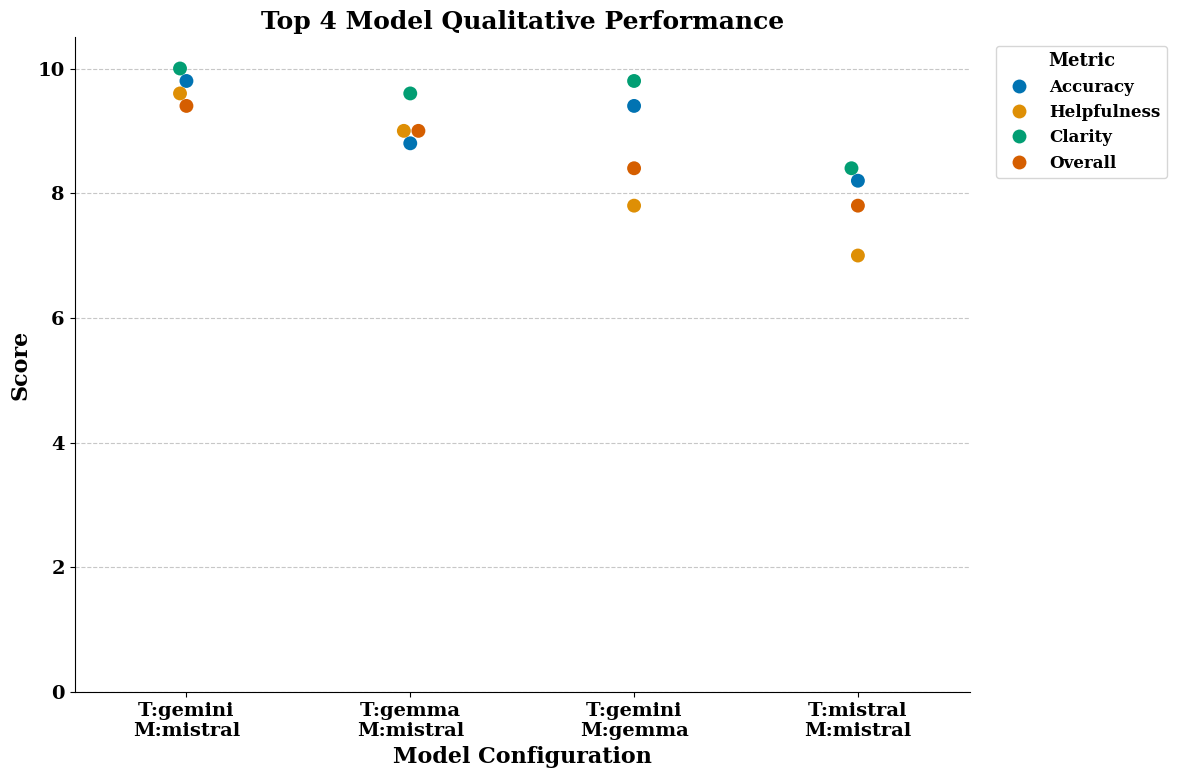

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Import Seaborn for easier dot plotting

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 14,         
    'font.weight': 'bold',   # Set global font weight to bold
    'axes.labelsize': 16,    
    'axes.titlesize': 18,    
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold'
})

# --- Hard-coded data for the top 4 models ---
data = {
    'Model': [
        'Teacher:gemini-Model:mistral', 
        'Teacher:gemma-Model:mistral', 
        'Teacher:gemini-Model:gemma', 
        'Teacher:mistral-Model:mistral'
    ],
    'Judge_Accuracy': [9.8, 8.8, 9.4, 8.2],
    'Judge_Helpfulness': [9.6, 9.0, 7.8, 7.0],
    'Judge_Clarity': [10.0, 9.6, 9.8, 8.4],
    'Judge_Overall': [9.4, 9.0, 8.4, 7.8]
}
top_4_models = pd.DataFrame(data)

# --- Data Preparation for Dot Plot ---
# We need to "melt" the DataFrame from wide format to long format
# This gives us one row per Model/Metric/Score combination
metrics = ['Judge_Accuracy', 'Judge_Helpfulness', 'Judge_Clarity', 'Judge_Overall']
df_long = top_4_models.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

# --- Clean up labels for plotting ---
# 1. Cleaner metric names for the legend
clean_labels = ['Accuracy', 'Helpfulness', 'Clarity', 'Overall']
metric_map = dict(zip(metrics, clean_labels))
df_long['Metric'] = df_long['Metric'].map(metric_map)

# 2. Shorter, multi-line model names for the x-axis
model_short_names = [
    'T:gemini\nM:mistral', 
    'T:gemma\nM:mistral', 
    'T:gemini\nM:gemma', 
    'T:mistral\nM:mistral'
]
model_map = dict(zip(top_4_models['Model'], model_short_names))
df_long['Model'] = df_long['Model'].map(model_map)


# --- Plot 2: Top 4 Model Comparison (Dot Plot) ---
# We use Seaborn's swarmplot, which is a dot plot that prevents overlap
fig, ax = plt.subplots(figsize=(12, 8)) # Wider figure for 4 categories

sns.swarmplot(
    data=df_long,
    x='Model',
    y='Score',
    hue='Metric',
    size=10,         # Size of the dots
    ax=ax,
    palette='colorblind' # Use a colorblind-friendly palette
)

# --- Customize the plot with prominent text ---
ax.set_ylim(0, 10.5) # Set Y-axis max as requested (with a little padding)
ax.set_title('Top 4 Model Qualitative Performance')
ax.set_xlabel('Model Configuration')
ax.set_ylabel('Score')

# Add a horizontal grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind dots

# Clean up the plot (removes top and right spines)
sns.despine()

# Adjust legend
# Place legend outside the plot area
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Metric', fontsize=12, title_fontsize=13)

# Use tight_layout() before saving
plt.tight_layout()

# --- Save the figure with high quality ---
# Note: Changed filenames to reflect the new plot type
plt.savefig('journal_dot_plot_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_dot_plot.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_dot_plot_600dpi.png' (High-res PNG)")
print("Saved 'journal_dot_plot.pdf' (Vector PDF)")

# plt.show() # Uncomment this to display the plot

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches # For custom legend
from adjustText import adjust_text     # For non-overlapping labels

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 20,         
    'font.weight': 'bold',   
    'axes.labelsize': 22,    
    'axes.titlesize': 24,    
    'xtick.labelsize': 20,   
    'ytick.labelsize': 20,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold',
    'mathtext.default': 'regular' 
})

# 2. Set Seaborn style
sns.set_style("whitegrid")

# --- Hard-coded average scores for all 9 models ---
data = {
    'Model': [
        'Teacher:gemini-Model:mistral', 
        'Teacher:gemma-Model:mistral', 
        'Teacher:gemini-Model:gemma', 
        'Teacher:mistral-Model:mistral', 
        'Teacher:mistral-Model:gemma', 
        'Teacher:mistral-Model:oss', 
        'Teacher:oss-Model:oss',
        'Teacher:oss-Model:mistral', 
        'Teacher:gemma-Model:oss'
    ],
    'Judge_Overall': [
        9.4, 9.0, 8.4, 7.8, 7.2, 7.0, 6.6, 5.6, 1.0
    ],
    'Cosine_Similarity': [
        0.84, 0.85, 0.79, 0.86, 0.82, 0.84, 0.73, 0.53, 0.40
    ]
}
model_avg_scores = pd.DataFrame(data)

# --- Define the shortcut label map ---
label_map = {
    'Teacher:gemini-Model:mistral': r'$T_G Mm$',
    'Teacher:gemma-Model:mistral': r'$T_g Mm$',
    'Teacher:gemini-Model:gemma': r'$T_G Mg$',
    'Teacher:mistral-Model:mistral': r'$T_m Mm$',
    'Teacher:mistral-Model:gemma': r'$T_m Mg$',
    'Teacher:mistral-Model:oss': r'$T_m Mo$',
    'Teacher:oss-Model:oss': r'$T_o Mo$',
    'Teacher:oss-Model:mistral': r'$T_o Mm$',
    'Teacher:gemma-Model:oss': r'$T_g Mo$'
}

# --- Plot 3: Performance vs. Similarity (Scatter Plot) ---
plt.figure(figsize=(13, 8))

# Get the list of unique models in the order they appear
unique_models = model_avg_scores['Model'].unique()
palette = sns.color_palette('viridis', n_colors=len(unique_models))
# Create a map of Model Name -> Color
color_map = dict(zip(unique_models, palette))

ax = sns.scatterplot(
    data=model_avg_scores,
    x='Cosine_Similarity',
    y='Judge_Overall',
    hue='Model',  
    palette=color_map, 
    s=200,        
    legend=False  
)

# --- Non-overlapping Labels ---
texts = []
for i, row in model_avg_scores.iterrows():
    label = label_map[row['Model']] 
    texts.append(plt.text(
        row['Cosine_Similarity'], 
        row['Judge_Overall'], 
        label,                
        fontsize=17,          
        fontweight='bold'
    ))

# Run the automatic adjustment
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.7))


# --- Custom Legend ---
custom_handles = []
for full_name in unique_models:
    shortcut = label_map[full_name]
    color = color_map[full_name]
    
    clean_name = full_name.replace('Teacher:', 'T:').replace('-Model:', ', M:')
    legend_label = f"{shortcut} : {clean_name}"
    
    patch = mpatches.Patch(color=color, label=legend_label)
    custom_handles.append(patch)

# --- MODIFIED LEGEND POSITION ---
# Add the new custom legend
ax.legend(
    handles=custom_handles, 
    title="Model Legend",
    loc='lower right', # <-- CHANGED: Place inside the plot
    fontsize=14,       
    title_fontsize=16,
    frameon=True,      # <-- NEW: Add a frame
    facecolor='white', # <-- NEW: Give it a solid background
    edgecolor='black'  # <-- NEW: Add a border
)

# --- Final Plot Customization ---
plt.title('Performance vs. Semantic Similarity')
plt.xlabel('Average Cosine Similarity (vs. Ground Truth)')
plt.ylabel('Average "Judge_Overall" Score (out of 10)')

plt.xlim(0.35, 0.9) 
plt.ylim(0, 10.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Use tight_layout() before saving
# This now just ensures labels/titles don't get cut off
plt.tight_layout()

# --- Save the figure with high quality ---
plt.savefig('journal_scatter_plot_final_legend_inside_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_scatter_plot_final_legend_inside.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_scatter_plot_final_legend_inside_600dpi.png' (High-res PNG)")
print("Saved 'journal_scatter_plot_final_legend_inside.pdf' (Vector PDF)")

# plt.show() # Uncomment this to display the plot

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

Saved 'journal_scatter_plot_final_legend_inside_600dpi.png' (High-res PNG)
Saved 'journal_scatter_plot_final_legend_inside.pdf' (Vector PDF)


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Added for styling

# --- Journal Quality Settings ---
# 1. Set global font properties for a more professional look
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 20,         
    'font.weight': 'bold',   # Set global font weight to bold
    'axes.labelsize': 22,    
    'axes.titlesize': 24,    
    'xtick.labelsize': 20,   
    'ytick.labelsize': 20,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold',
    'mathtext.default': 'regular' # For subscripts
})

# 2. Set Seaborn style
sns.set_style("whitegrid") # Use whitegrid style

# --- Data ---
# Model configurations
# Using LaTeX shortcuts for consistency with your other plots
models = [r'$T_G Mm$', r'$T_g Mm$', r'$T_G Mg$']

# Qualitative evaluation scores
depth_v1 = [8.65, 8.53, 9.21]    # From Gemini/Gemma teacher data (V1)
depth_v2 = [7.06, 8.06, 9.40]    # From self-improved data (V2)
clarity_v1 = [8.76, 9.17, 9.21]
clarity_v2 = [6.96, 7.95, 9.40]

# --- Plot Configuration ---
x = np.arange(len(models))
width = 0.18 # Bar width

# Increased figsize for larger fonts
fig, ax = plt.subplots(figsize=(12, 8))

# Bars for Depth
# zorder=3 places bars in front of the gridlines
ax.bar(x - width, depth_v1, width, label='Depth (V1)', edgecolor='black', zorder=3)
ax.bar(x, depth_v2, width, label='Depth (V2)', edgecolor='black', hatch='//', zorder=3)

# Bars for Clarity
ax.bar(x + width, clarity_v1, width, label='Clarity (V1)', edgecolor='black', zorder=3)
ax.bar(x + 2*width, clarity_v2, width, label='Clarity (V2)', edgecolor='black', hatch='//', zorder=3)

# --- Styling ---
# Fontsizes are now controlled by rcParams
ax.set_ylabel('Qualitative Score (0–10)')
ax.set_xlabel('Model Configuration')
ax.set_title('Comparison of Teacher-Generated (V1) and Self-Improved (V2) Datasets')
ax.set_xticks(x + width/2)
ax.set_xticklabels(models)

# Set Y-axis limit
ax.set_ylim(0, 10.5)

# Adjusted legend fontsize to be large but fit
ax.legend(fontsize=18, ncol=2, loc='upper left')

# grid is handled by sns.set_style("whitegrid")

plt.tight_layout()

# --- Save the figure with high quality ---
plt.savefig('journal_barchart_comparison_600dpi.png', dpi=600, bbox_inches='tight')
plt.savefig('journal_barchart_comparison.pdf', format='pdf', bbox_inches='tight')

print("Saved 'journal_barchart_comparison_600dpi.png' (High-res PNG)")
print("Saved 'journal_barchart_comparison.pdf' (Vector PDF)")

# plt.show() # Uncomment to display

# Reset matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

Saved 'journal_barchart_comparison_600dpi.png' (High-res PNG)
Saved 'journal_barchart_comparison.pdf' (Vector PDF)


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

# --- Journal Quality Settings ---
plt.rcParams.update({
    'font.family': 'serif',  
    'font.size': 20,         
    'font.weight': 'bold',   
    'axes.labelsize': 22,    
    'axes.titlesize': 24,    
    'xtick.labelsize': 20,   
    'ytick.labelsize': 20,   
    'axes.labelweight': 'bold', 
    'axes.titleweight': 'bold',
    'mathtext.default': 'regular' 
})

sns.set_style("whitegrid") 

# --- Data ---
models = [r'$T_G Mm$', r'$T_g Mm$', r'$T_G Mg$', r'$T_m Mm$']
depth_v1 = [8.65, 8.53, 9.21, 6.12]
depth_v2 = [7.06, 8.06, 9.40, 6.46]
clarity_v1 = [8.76, 9.17, 9.21, 7.65]
clarity_v2 = [6.96, 7.95, 9.40, 7.70]
specificity_v1 = [8.90, 8.60, 9.21, 7.91]
specificity_v2 = [8.10, 8.30, 9.40, 8.84]

# --- Plot Configuration ---
x = np.arange(len(models))
width = 0.12 
fig, ax = plt.subplots(figsize=(14, 8))

# Bars
ax.bar(x - width*2, depth_v1, width, label='Depth (V1)', edgecolor='black', zorder=3)
ax.bar(x - width, depth_v2, width, label='Depth (V2)', edgecolor='black', hatch='//', zorder=3)
ax.bar(x, clarity_v1, width, label='Clarity (V1)', edgecolor='black', zorder=3)
ax.bar(x + width, clarity_v2, width, label='Clarity (V2)', edgecolor='black', hatch='//', zorder=3)
ax.bar(x + width*2, specificity_v1, width, label='Specificity (V1)', edgecolor='black', zorder=3)
ax.bar(x + width*3, specificity_v2, width, label='Specificity (V2)', edgecolor='black', hatch='//', zorder=3)

# --- Styling ---
ax.set_ylabel('Qualitative Score (0–10)')
ax.set_xlabel('Model Configuration')
ax.set_xticks(x + width/2) 
ax.set_xticklabels(models)
ax.set_ylim(0, 10.5)
ax.set_axisbelow(True) 

# --- NEW LEGEND & TITLE PLACEMENT ---
# 1. Place the legend high up, but leave room for a title above it.
ax.legend(fontsize=18, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.18)) 

# 2. Manually set the title's y-position to be *above* the legend (e.g., y=1.25)
ax.set_title(
    'Comparison of Teacher-Generated (V1) vs. Self-Improved (V2) Datasets',
    y=1.25 # Adjust this value if needed (1.0 is default)
)

# tight_layout() is no longer needed here as we are manually placing the title
# and bbox_inches='tight' in savefig will handle cropping.

# --- Save the figure with high quality ---
plt.savefig(
    'journal_barchart_3metrics_final_600dpi.png', 
    dpi=600, 
    bbox_inches='tight' # This will crop the final image to fit everything
)
plt.savefig(
    'journal_barchart_3metrics_final.pdf', 
    format='pdf', 
    bbox_inches='tight'
)

print("Saved 'journal_barchart_3metrics_final_600dpi.png' (High-res PNG)")
print("Saved 'journal_barchart_3metrics_final.pdf' (Vector PDF)")

# plt.show()
plt.rcParams.update(plt.rcParamsDefault)

Saved 'journal_barchart_3metrics_final_600dpi.png' (High-res PNG)
Saved 'journal_barchart_3metrics_final.pdf' (Vector PDF)
